In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [5]:
sys.path.append('C:/Users/rishe/Dissertation')

In [27]:
EXP_ID = f'exp_6_lstm_with_log_transform_seasonal_focal_loss'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [7]:
df_long = pd.read_parquet(DATA_PATH)

In [8]:
df_long.shape

(4741665, 11)

In [9]:
df_long['station_id'].nunique()

293

### Data Pre-processing

In [10]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [11]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [12]:
df_long = df_long.dropna(subset=['rainfall'])

In [13]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [14]:
station_summary.head()

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847


In [15]:
station_summary['rainy_days'].sum()

1121149

### Log Transformation

In [16]:
def log_rain_transform(y):
    return torch.log1p(y)

def inverse_log_rain_transform(y):
    return torch.expm1(y)

In [17]:
class TargetTransformDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]

        # unpack (assumes your order)
        X, y, *rest = sample

        if self.transform is not None:
            y = self.transform(y)

        return (X, y, *rest)


### Data Splits

In [18]:
from utils.data_utils.data_helper_utils import temporal_split

In [19]:
df_train, df_val, df_test = temporal_split(df_long)

### Dataset Preparation

In [36]:
from utils.data_utils.dataset_files.dataset_with_meta_features import RainfallWindowDataset

In [37]:
# Experiment configuration
H = 1  # Horizon
L = 30  # Window length
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Window length: {L}")
print(f"Horizon: {H}")

Device: cuda
Window length: 30
Horizon: 1


In [38]:
train_ds = RainfallWindowDataset(
    df_train,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

val_ds = RainfallWindowDataset(
    df_val,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

test_ds = RainfallWindowDataset(
    df_test,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

Train samples: 2762479
Val samples: 585253
Test samples: 585402


In [40]:
train_ds = TargetTransformDataset(
    train_ds,
    transform=log_rain_transform
)

val_ds = TargetTransformDataset(
    val_ds,
    transform=log_rain_transform
)

test_ds = TargetTransformDataset(
    test_ds,
    transform=log_rain_transform
)


In [42]:
train_ds.base_dataset.X.shape

torch.Size([2762479, 30, 7])

### Import Loss Functions and Models

In [43]:
# Import custom loss function
from utils.loss import SeasonalFocalMSELoss

# Import model trainer that accepts custom criterion
from models.lstm_with_seasonal_criterion import RainfallLSTM, train_model, evaluate_on_test, collect_test_predictions

# Import metrics

from utils.metric_utils.metrics import rmse, mae, bias, nrmse, seasonal_subset, stationwise_metrics

print("Imports successful!")

Imports successful!


### Training with Focal Loss

In [44]:
# Focal loss configuration
FOCAL_GAMMA = 2.0
criterion = SeasonalFocalMSELoss(gamma=FOCAL_GAMMA, reduction='mean')

print(f"Criterion: SeasonalFocalMSELoss (gamma={FOCAL_GAMMA})")
print(f"Criterion type: {type(criterion)}")

Criterion: SeasonalFocalMSELoss (gamma=2.0)
Criterion type: <class 'utils.loss.SeasonalFocalMSELoss'>


In [45]:
# Model configuration
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
HIDDEN_DIM = 128

# Setup paths
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"

print(f"Model save path: {model_save_path}")
print(f"Log save path: {log_save_path}")

Model save path: C:/Users/rishe/Dissertation/experiments/saved_models/exp_6_lstm_with_log_transform_seasonal_focal_loss
Log save path: C:/Users/rishe/Dissertation/experiments/logs/exp_6_lstm_with_log_transform_seasonal_focal_loss


In [46]:
# Create model
model = RainfallLSTM(
    input_dim=train_ds.base_dataset.X.shape[-1],
    hidden_dim=HIDDEN_DIM
).to(device)

print(f"Model created successfully")
print(f"Input dim: {train_ds.base_dataset.X.shape[-1]}")
print(f"Hidden dim: {HIDDEN_DIM}")

Model created successfully
Input dim: 7
Hidden dim: 128


In [47]:
# Train model with focal loss as criterion
from datetime import datetime

print(f"\n{'='*60}")
print(f"Starting training with FocalMSELoss")
print(f"Start time: {datetime.now()}")
print(f"{'='*60}")

trained_model = train_model(
    train_ds=train_ds,
    val_ds=val_ds,
    model=model,
    device=device,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    criterion=criterion,  # Pass FocalMSELoss as criterion
    save_dir=model_save_path,
    log_dir=log_save_path,
    experiment_name=EXP_ID
)

print(f"\nEnd time: {datetime.now()}")
print(f"Training completed successfully!")


Starting training with FocalMSELoss
Start time: 2026-02-09 15:57:22.269453
2026-02-09 15:57:22 | INFO | Starting training
2026-02-09 15:57:22 | INFO | Device: cuda


Train:   0%|          | 0/43164 [00:00<?, ?it/s]

Eval:   0%|          | 0/9145 [00:00<?, ?it/s]

2026-02-09 16:00:24 | INFO | Epoch 001 | Train Loss: 1.577543 | Val Loss: 1.604249
2026-02-09 16:00:24 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_6_lstm_with_log_transform_seasonal_focal_loss\epoch_1.pt


Train:   0%|          | 0/43164 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/9145 [00:00<?, ?it/s]

2026-02-09 16:39:05 | INFO | Epoch 009 | Train Loss: 1.557240 | Val Loss: 1.601805
2026-02-09 16:39:05 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_6_lstm_with_log_transform_seasonal_focal_loss\epoch_9.pt


Train:   0%|          | 0/43164 [00:00<?, ?it/s]

Eval:   0%|          | 0/9145 [00:00<?, ?it/s]

2026-02-09 16:41:51 | INFO | Epoch 010 | Train Loss: 1.556917 | Val Loss: 1.599369
2026-02-09 16:41:51 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_6_lstm_with_log_transform_seasonal_focal_loss\epoch_10.pt
2026-02-09 16:41:51 | INFO | Training completed

End time: 2026-02-09 16:41:51.082831
Training completed successfully!


In [ ]:
# Evaluate on test set
print(f"\n{'='*60}")
print(f"Evaluating on test set")
print(f"{'='*60}")

test_metrics = evaluate_on_test(
    test_ds,
    trained_model,
    device
)

print("\nTest Metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


Evaluating on test set
2026-02-09 16:45:49 | INFO | Overall Test Metrics
2026-02-09 16:45:49 | INFO | RMSE: 1.0521
2026-02-09 16:45:49 | INFO | MAE: 0.8277
2026-02-09 16:45:49 | INFO | Bias: 0.1981
2026-02-09 16:45:49 | INFO | NRMSE: 1.5519
2026-02-09 16:45:50 | INFO | MONSOON RMSE: 1.3853
2026-02-09 16:45:50 | INFO | NON_MONSOON RMSE: 0.7756

Test Metrics:
RMSE: 1.0521
MAE: 0.8277
Bias: 0.1981
NRMSE: 1.5519
monsoon_RMSE: 1.3853
non_monsoon_RMSE: 0.7756


In [49]:
# results = evaluate_on_test(
#     test_ds,
#     model,
#     device=device
# )

# OR if using collect_test_predictions
df = collect_test_predictions(test_ds, model, device)

df["y_phys"] = np.expm1(df["y"])
df["yhat_phys"] = np.expm1(df["yhat"])


In [51]:
df.head()

,y,yhat,month,station_id,lat,lon,y_phys,yhat_phys
0,0.000000,1.290722,8,AKRIGANJ,NaN,NaN,0.0,2.635409
1,0.000000,1.288421,8,AKRIGANJ,NaN,NaN,0.0,2.627054
2,0.000000,1.229918,8,AKRIGANJ,NaN,NaN,0.0,2.420948
3,0.000000,1.189716,8,AKRIGANJ,NaN,NaN,0.0,2.286147
4,1.757858,1.151175,8,AKRIGANJ,NaN,NaN,4.8,2.161905


In [53]:
df_res = df.copy(deep=True)

In [54]:
df['y'] = df['y_phys']
df['yhat'] = df['yhat_phys']

### Evaluation

In [29]:
# Load best checkpoint (epoch 9)
ckpt_path = f"{model_save_path}/epoch_9.pt"
print(f"Loading checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)
trained_model.load_state_dict(checkpoint["model_state_dict"])
trained_model.to(device)
trained_model.eval()

print("Checkpoint loaded successfully!")

Loading checkpoint: C:/Users/rishe/Dissertation/experiments/saved_models/exp_5_lstm_with_seasonal_focal_loss/epoch_9.pt
Checkpoint loaded successfully!


C:\Users\rishe\AppData\Local\Temp\ipykernel_6420\3334625799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


In [30]:
# Collect test predictions
df_eval = collect_test_predictions(
    test_ds=test_ds,
    model=trained_model,
    device=device
)

print(f"Predictions collected: {len(df_eval)} samples")
df_eval.head()

Predictions collected: 585402 samples


,y,yhat,month,station_id,lat,lon
0,0.0,6.918638,8,AKRIGANJ,NaN,NaN
1,0.0,7.012896,8,AKRIGANJ,NaN,NaN
2,0.0,6.849843,8,AKRIGANJ,NaN,NaN
3,0.0,6.696322,8,AKRIGANJ,NaN,NaN
4,4.8,6.507463,8,AKRIGANJ,NaN,NaN


In [56]:
df_eval = df.copy(deep=True)

In [57]:
# Calculate error metrics
df_eval["error"] = df_eval["y"] - df_eval["yhat"]

# Create masks for analysis
rainy_mask = df_eval["y"] > 0
non_rainy_mask = df_eval["y"] == 0

monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

monsoon_mask = df_eval["month"].isin(monsoon_months)
non_monsoon_mask = df_eval["month"].isin(non_monsoon_months)

print("Error metrics and masks calculated")

Error metrics and masks calculated


### Overall Evaluation Metrics

In [58]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

print("\nOverall Evaluation Metrics (FocalMSELoss):")
print(pd.DataFrame(overall_metrics, index=["Focal Loss Model"]).round(4))


Overall Evaluation Metrics (FocalMSELoss):
                     RMSE     MAE   Bias   NRMSE
Focal Loss Model  16.9755  5.6565 -3.626  3.0325


### Seasonal Evaluation

In [59]:
df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

print("\nSeasonal Performance:")
print(seasonal_metrics.round(4))


Seasonal Performance:
                RMSE      MAE    Bias
Monsoon      24.8780  11.1045 -7.7931
Non-Monsoon   9.0724   2.2657 -1.0325


### Per-Station Performance

In [34]:
df_station_metrics = stationwise_metrics(df_eval)

print("\nStation-wise metrics summary:")
print(df_station_metrics.describe().round(4))


Station-wise metrics summary:
           RMSE       MAE      Bias      Count
count  283.0000  283.0000  283.0000   283.0000
mean    13.8586    6.6513    0.3859  2068.5583
std      6.5621    2.9531    1.2726  1583.1979
min      0.4348    0.4185   -4.7615     2.0000
25%     10.2116    5.0584    0.0715   799.5000
50%     12.3939    5.8455    0.5801  1747.0000
75%     16.3728    8.0768    0.9829  2916.0000
max     40.6743   21.0402    6.1594  6533.0000


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [61]:
df_station_metrics = stationwise_metrics(df_eval)

print("\nStation-wise metrics summary:")
print(df_station_metrics.describe().round(4))


Station-wise metrics summary:
           RMSE       MAE      Bias      Count
count  283.0000  283.0000  283.0000   283.0000
mean    14.6141    5.3921   -3.3854  2068.5583
std      7.5438    3.0034    2.6771  1583.1979
min      0.2374    0.2354  -18.5387     2.0000
25%     10.6699    3.7912   -4.2822   799.5000
50%     12.9160    4.5856   -2.6909  1747.0000
75%     17.3547    6.5320   -1.9505  2916.0000
max     43.0244   22.1086    1.6023  6533.0000


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


### Month-wise RMSE

C:\Users\rishe\AppData\Local\Temp\ipykernel_35992\1191928291.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


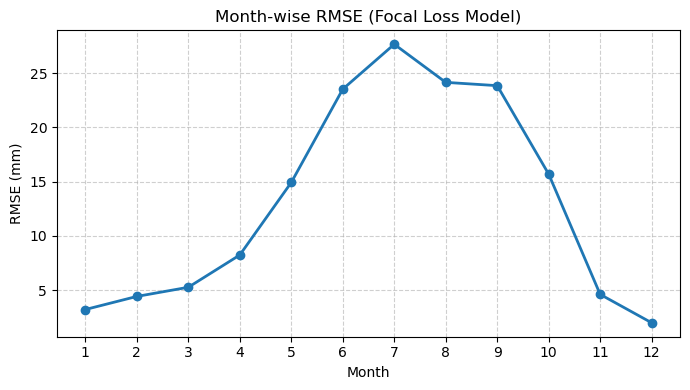

In [62]:
# Compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE (Focal Loss Model)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Error Distribution Analysis

In [63]:
# Error statistics
print("Error Statistics:")
print((df_eval['error']).describe(percentiles=[0.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, .95, .96, .97, .98, .99]).round(4))

Error Statistics:
count    585402.0000
mean          3.6260
std          16.5837
min         -40.9629
10%          -2.5059
20%          -1.6690
25%          -1.3271
30%          -1.0490
40%          -0.6456
50%          -0.4796
60%          -0.3956
70%          -0.2649
75%          -0.2178
80%           1.3055
90%          13.1271
95%          28.5894
96%          34.4244
97%          42.2991
98%          54.4953
99%          77.6520
max         631.0555
Name: error, dtype: float64


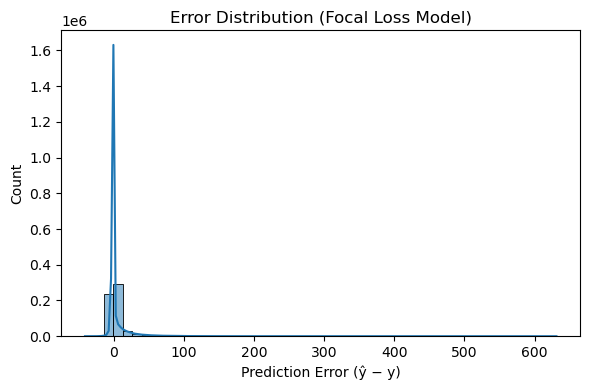

In [64]:
# Error histogram
plt.figure(figsize=(6, 4))
sns.histplot(df_eval['error'], bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution (Focal Loss Model)")
plt.tight_layout()
plt.show()

### Rainy vs Non-Rainy Analysis

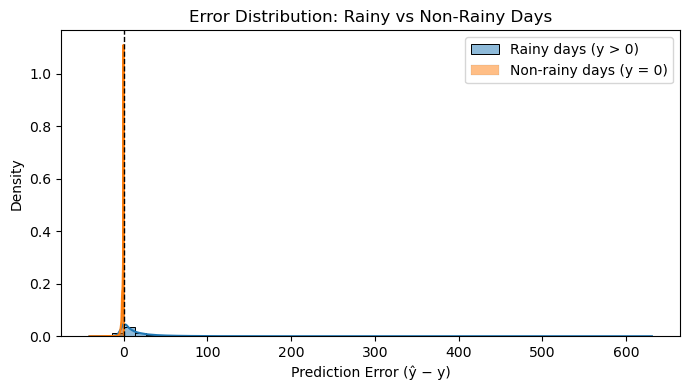

In [65]:
# Error histogram by rainfall regime
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()

### Monsoon vs Non-Monsoon Analysis

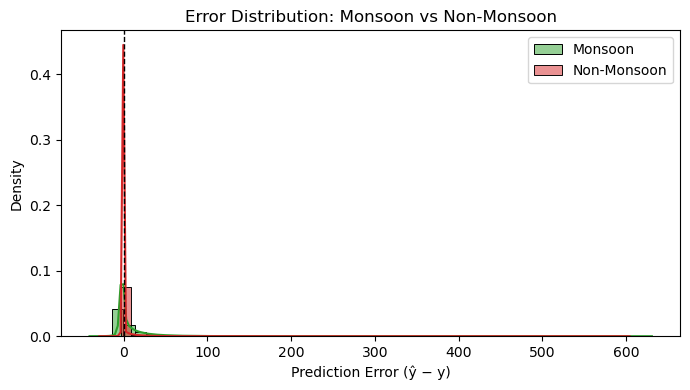

In [66]:
# Error histogram by season
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()

### Conditional RMSE Analysis

In [67]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

conditional_metrics = pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])

print("\nConditional RMSE by Rainfall Regime:")
print(conditional_metrics.round(4))


Conditional RMSE by Rainfall Regime:
          Regime       RMSE        MAE       Bias   Count
0      Non-rainy   1.852400   1.186100   1.186100  418964
1     Light rain   3.886300   2.871100  -0.616000   82155
2  Moderate rain  21.686701  18.910500 -18.771400   68338
3     Heavy rain  91.629898  80.666298 -80.666298   15945


### Baseline Comparison

In [68]:
# Baseline models
yhat_zero = np.zeros_like(df_eval.y)
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Focal Loss Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

print("\nBaseline Comparison:")
print(baseline_table.round(4))


Baseline Comparison:
                       RMSE     MAE
Focal Loss Model  16.975500  5.6565
Zero Predictor    18.398399  5.5978
Mean Predictor    17.526100  8.6384


### Scatter Plot: True vs Predicted

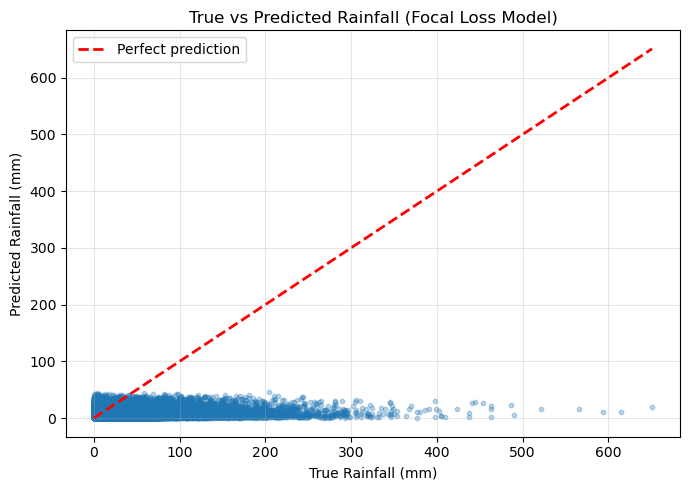

In [69]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_eval["y"],
    df_eval["yhat"],
    alpha=0.3,
    s=10
)

# Perfect prediction line
max_val = max(df_eval["y"].max(), df_eval["yhat"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted Rainfall (Focal Loss Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

In [70]:
summary_data = [
    {"Metric": "RMSE", "Value": overall_metrics["RMSE"]},
    {"Metric": "MAE", "Value": overall_metrics["MAE"]},
    {"Metric": "Bias", "Value": overall_metrics["Bias"]},
    {"Metric": "NRMSE", "Value": overall_metrics["NRMSE"]},
]

print(f"\n{'='*60}")
print(f"EXPERIMENT SUMMARY: FocalMSELoss (γ={FOCAL_GAMMA})")
print(f"{'='*60}")
print(f"Window Length: {L} days")
print(f"Horizon: {H} day")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Hidden Dimension: {HIDDEN_DIM}")
print(f"\nResults:")
print(pd.DataFrame(summary_data).to_string(index=False))
print(f"{'='*60}")


EXPERIMENT SUMMARY: FocalMSELoss (γ=2.0)
Window Length: 30 days
Horizon: 1 day
Batch Size: 64
Epochs: 10
Learning Rate: 0.001
Hidden Dimension: 128

Results:
Metric     Value
  RMSE 16.975483
   MAE  5.656525
  Bias -3.626045
 NRMSE  3.032530
